
#1. Análise Exploratória de Dados e Modelo Baseline - Heart Disease

## Objetivo

Este notebook tem como objetivo realizar uma análise exploratória de dados (EDA),
realizar o pré-processamento das informações e desenvolver um modelo de Machine
Learning como baseline utilizando o dataset Heart Disease.

O problema consiste em prever a presença ou ausência de doença cardíaca em pacientes
a partir de características clínicas, como idade, colesterol, pressão arterial e
frequência cardíaca.

As etapas realizadas neste projeto são:

- Carregamento do dataset;
- Análise inicial dos dados;
- Estatísticas descritivas;
- Identificação de valores ausentes;
- Criação de visualizações;
- Extração de insights;
- Preparação dos dados para Machine Learning;
- Treinamento de um modelo baseline;
- Avaliação do modelo.

##2. Importação das bibliotecas

Nesta etapa são importadas as bibliotecas utilizadas no projeto.

As principais bibliotecas utilizadas são:

- Pandas: manipulação e análise dos dados;
- NumPy: operações matemáticas;
- Matplotlib e Seaborn: criação das visualizações;
- Scikit-learn: preparação dos dados e treinamento do modelo.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

##3. Carregamento dos dados

O dataset utilizado neste projeto é o Heart Disease, disponibilizado pelo
UCI Machine Learning Repository.

Ele contém informações clínicas de pacientes, como idade, colesterol,
pressão arterial e resultados de exames.

A variável alvo representa a presença ou ausência de doença cardíaca.

- 0: ausência de doença cardíaca
- 1: presença de doença cardíaca

In [ ]:
!pip install ucimlrepo

In [ ]:
from ucimlrepo import fetch_ucirepo

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

df = pd.concat([X, y], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


Após carregar os dados, verificamos os nomes das colunas para identificar
a variável alvo e as características utilizadas pelo modelo.

In [ ]:
df.columns

Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num'],
      dtype='object')

In [ ]:
df = df.rename(columns={"num":"target"})

In [ ]:
# Transforma o problema em classificação binária
df["target"] = df["target"].apply(lambda x: 0 if x == 0 else 1)

# Conferindo as classes
print(df["target"].value_counts())

target
0    164
1    139
Name: count, dtype: int64


# 4. Conhecendo os dados

A função info() apresenta informações gerais do dataset, incluindo:

- Quantidade de registros;
- Nome das colunas;
- Tipos de dados;
- Quantidade de valores preenchidos.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  target    303 non-null    int64  
dtypes: float64(3), int64(11)
memory usage: 33.3 KB


A função describe() apresenta estatísticas das variáveis numéricas.

São exibidas informações como:

- Média;
- Desvio padrão;
- Valores mínimo e máximo;
- Quartis.

In [ ]:
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,1.000000


A identificação de valores ausentes é importante antes do treinamento
do modelo, pois valores faltantes podem prejudicar o aprendizado.

A função isnull().sum() contabiliza os valores nulos existentes.

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


# 5. Análise Exploratória dos Dados (EDA)

## Distribuição da idade

O histograma permite analisar como a idade dos pacientes está distribuída.

Essa visualização ajuda a identificar a faixa etária predominante no dataset.

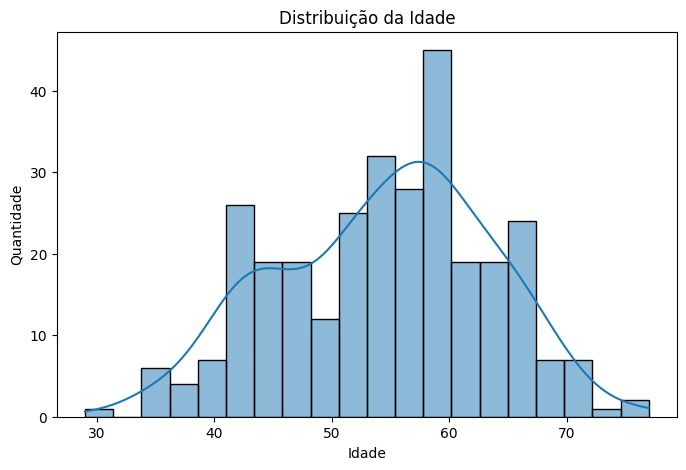

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=20,
    kde=True
)

plt.title("Distribuição da Idade")
plt.xlabel("Idade")
plt.ylabel("Quantidade")

plt.show()

## Distribuição do colesterol

O boxplot permite analisar a dispersão dos valores de colesterol
e identificar possíveis valores extremos.

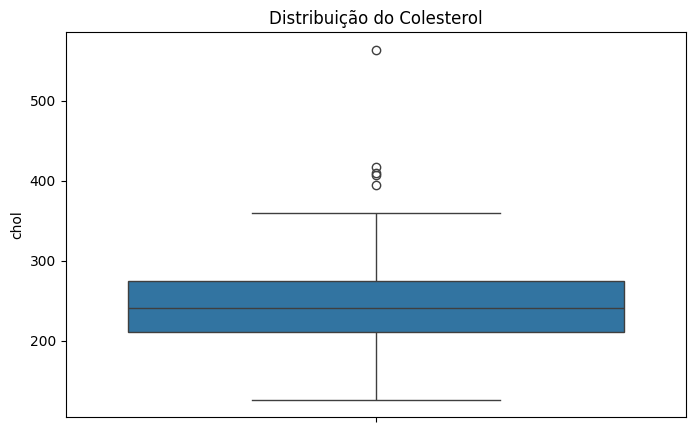

In [ ]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    y="chol"
)

plt.title("Distribuição do Colesterol")

plt.show()

## Relação entre idade e frequência cardíaca máxima

O gráfico de dispersão permite observar a relação entre duas variáveis.

As cores representam a variável alvo, permitindo comparar pacientes
com e sem doença cardíaca.

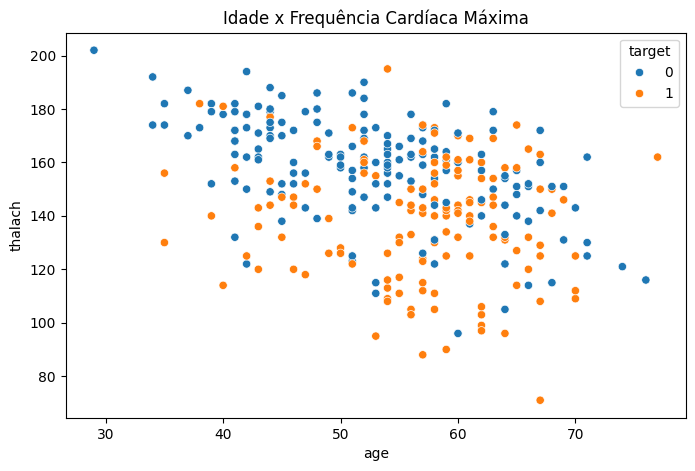

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="age",
    y="thalach",
    hue="target"
)

plt.title("Idade x Frequência Cardíaca Máxima")

plt.show()

## Matriz de correlação

A matriz de correlação mostra a relação entre as variáveis numéricas.

Valores próximos de 1 indicam uma correlação positiva,
enquanto valores próximos de -1 indicam uma correlação negativa.

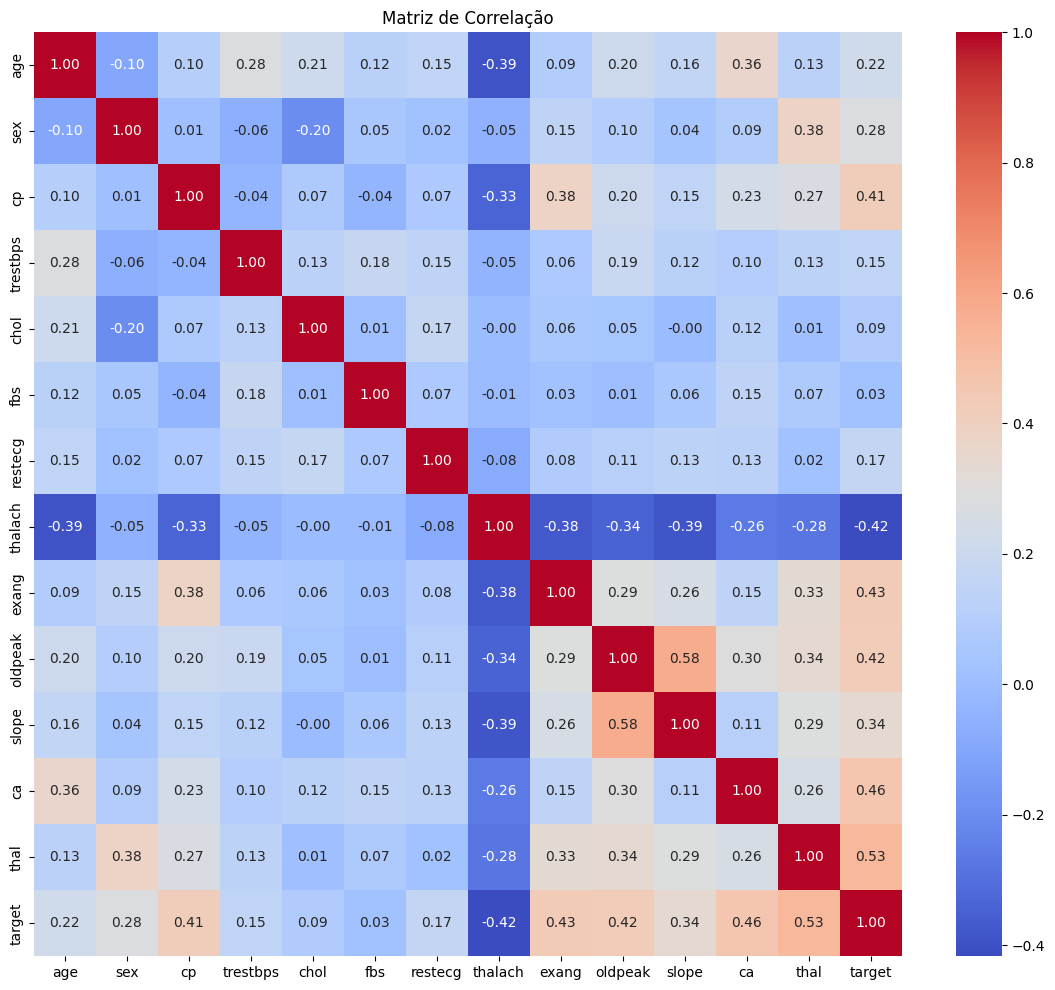

In [ ]:
plt.figure(figsize=(14,12))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Matriz de Correlação")

plt.show()

#6. Insights do EDA

Após a análise exploratória, foram encontrados os seguintes insights:

### Insight 1
A maioria dos pacientes analisados possui idade concentrada
entre aproximadamente 40 e 60 anos.

### Insight 2
A variável colesterol apresenta alguns valores extremos,
indicando a presença de possíveis outliers.

### Insight 3
A frequência cardíaca máxima apresenta diferenças entre pacientes
com e sem doença cardíaca, indicando que essa variável pode ser
importante para a classificação.

## Tratamento de valores ausentes

Durante a análise dos dados foram identificados valores ausentes em algumas
variáveis.

Como modelos de Machine Learning não conseguem trabalhar diretamente com
valores vazios, foi realizado o preenchimento desses valores utilizando a
mediana de cada variável.

A mediana foi escolhida porque é menos influenciada por valores extremos.

In [ ]:
# Substitui valores não numéricos por NaN
df = df.replace("?", np.nan)


# Converte todas as colunas para número
df = df.apply(pd.to_numeric)


# Verifica novamente os valores ausentes
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


In [ ]:
# Preenchimento dos valores ausentes pela mediana

df = df.fillna(df.median())

In [ ]:
# Preenchimento dos valores ausentes pela mediana

df = df.fillna(df.median())

# 7. Pré-processamento

Nesta etapa os dados são separados em:

- X: variáveis independentes utilizadas pelo modelo;
- y: variável alvo que será prevista.

In [ ]:
X = df.drop("target", axis=1)

y = df["target"]

O dataset será dividido em dados de treinamento e teste.

O conjunto de treinamento será utilizado para ensinar o modelo,
enquanto o conjunto de teste será utilizado para avaliar seu desempenho.

Foi utilizada a divisão:

- 80% treinamento;
- 20% teste.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

As variáveis possuem diferentes escalas.

O StandardScaler realiza a padronização dos dados,
fazendo com que as variáveis tenham escalas semelhantes.

Esse processo evita que variáveis com valores maiores tenham
maior influência no modelo.

In [ ]:
scaler = StandardScaler()


X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# 8. Modelo Baseline

## Regressão Logística

Foi escolhido como modelo baseline a Regressão Logística.

Esse algoritmo é utilizado para problemas de classificação binária,
onde existem duas possíveis respostas.

Neste caso:

- 0: paciente sem doença cardíaca;
- 1: paciente com doença cardíaca.

O objetivo é criar uma primeira referência de desempenho.

In [ ]:
modelo = LogisticRegression(
    max_iter=1000
)


modelo.fit(
    X_train,
    y_train
)

LogisticRegression(max_iter=1000)

# 9. Avaliação do modelo

Após o treinamento, o modelo será avaliado utilizando:

- Acurácia: percentual de previsões corretas;
- Classification Report: métricas de precisão, recall e F1-score.

In [ ]:
pred = modelo.predict(X_test)


print(
    "Acurácia:",
    accuracy_score(y_test,pred)
)

Acurácia: 0.8688524590163934


In [ ]:
print(
    classification_report(
        y_test,
        pred
    )
)

              precision    recall  f1-score   support

           0       0.93      0.82      0.87        33
           1       0.81      0.93      0.87        28

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.88      0.87      0.87        61



# Matriz de Confusão

A matriz de confusão permite visualizar a quantidade de previsões
corretas e incorretas realizadas pelo modelo.

Ela apresenta:

- Verdadeiros positivos;
- Verdadeiros negativos;
- Falsos positivos;
- Falsos negativos.

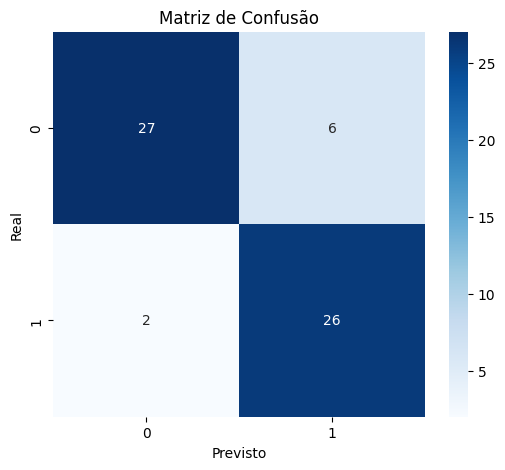

In [ ]:
cm = confusion_matrix(
    y_test,
    pred
)


plt.figure(figsize=(6,5))


sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)


plt.xlabel("Previsto")

plt.ylabel("Real")

plt.title("Matriz de Confusão")


plt.show()

# Conclusão

Neste projeto foi realizada uma análise exploratória do dataset Heart Disease,
seguida pelo pré-processamento dos dados e treinamento de um modelo baseline.

A análise permitiu identificar características importantes dos pacientes e
compreender possíveis relações entre as variáveis clínicas e a presença de
doença cardíaca.

Após o tratamento dos dados e escalonamento das variáveis, foi treinado um
modelo de Regressão Logística, que servirá como referência para futuras
comparações com modelos mais avançados.